In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# --- 1. 设置环境 ---
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] # 兼容中文字体
plt.rcParams['axes.unicode_minus'] = False # 解决负号 '-' 显示为方块的问题

# --- 2. 加载数据 ---
print("正在加载数据...")
file_path = '../data/kg.csv'

try:
    df = pd.read_csv(file_path, dtype=str, low_memory=False)
    print(f"✅ 数据加载成功！形状: {df.shape}")
    print(f"📋 列名预览: {list(df.columns)}")
    # --- 新增：创建输出目录 ---
    import os
    output_dir = '../out/kg_structure'
    os.makedirs(output_dir, exist_ok=True) # 如果目录不存在则创建
    print(f"✅ 输出目录已准备就绪: {output_dir}")
except Exception as e:
    print(f"❌ 读取失败: {e}")
    # 模拟数据保持代码可运行
    data = [['protein_protein','ppi',0,9796,'gene/protein','PHYHIP','NCBI',8889,56992,'gene/protein','KIF15','NCBI']]
    df = pd.DataFrame(data, columns=['relation','display_relation','x_index','x_id','x_type','x_name','x_source','y_index','y_id','y_type','y_name','y_source'])

# --- 3. 数据清洗 ---
df.dropna(subset=['x_type', 'y_type', 'relation', 'x_id', 'y_id'], inplace=True)

# --- 4. 核心统计 (修复重复 + 新增节点统计) ---

# A. 新增：总结点数统计 (核心新增点)
all_node_ids = pd.concat([df['x_id'], df['y_id']]) # 合并所有ID
unique_node_count = all_node_ids.nunique() # 去重计数

print("\n--- 📊 基础统计修正版 ---")
print(f"总边数 (三元组数量): {len(df)}")
print(f"✅ 总结点数 (唯一实体数量): {unique_node_count}") # 输出结果

# B. 修复节点类型分布 (消除重复行)
# 旧逻辑: concat -> 导致重复
# 新逻辑: 先分别统计 count, 再用 add() 按索引(类型名)相加
x_type_counts = df['x_type'].value_counts()
y_type_counts = df['y_type'].value_counts()
# 使用 add 方法自动对齐索引并求和，fill_value=0 处理只在一侧出现的类型
type_distribution = x_type_counts.add(y_type_counts, fill_value=0).astype(int).sort_values(ascending=False)

print("\n--- 🧬 1. 节点类型分布 (已去重) ---")
print(type_distribution.head())

# C. 修复数据源分布 (同理)
x_source_counts = df['x_source'].value_counts()
y_source_counts = df['y_source'].value_counts()
source_distribution = x_source_counts.add(y_source_counts, fill_value=0).astype(int).sort_values(ascending=False)

print("\n--- 🌐 2. 数据源分布 (已去重) ---")
print(source_distribution.head())

# --- 5. 原有其他统计 ---
relation_counts = df['relation'].value_counts()
print("\n--- 🔗 3. 关系类型分布 ---")
print(f"共有 {len(relation_counts)} 种关系。Top 5:")
print(relation_counts.head())

# D. 异构图模式分析
print("\n--- 🕸️ 4. 异构图连接模式 (Schema) ---")
schema_patterns = df.groupby(['x_type', 'relation', 'y_type']).size().reset_index(name='count')
schema_patterns = schema_patterns.sort_values('count', ascending=False)
print("前 5 种最常见的结构模式:")
print(schema_patterns.head())



正在加载数据...
✅ 数据加载成功！形状: (8100498, 12)
📋 列名预览: ['relation', 'display_relation', 'x_index', 'x_id', 'x_type', 'x_name', 'x_source', 'y_index', 'y_id', 'y_type', 'y_name', 'y_source']
✅ 输出目录已准备就绪: ../out/kg_structure

--- 📊 基础统计修正版 ---
总边数 (三元组数量): 8100498
✅ 总结点数 (唯一实体数量): 90067

--- 🧬 1. 节点类型分布 (已去重) ---
x_type
drug                5611392
gene/protein        5262458
anatomy             3132308
disease              682488
effect/phenotype     514192
Name: count, dtype: int64

--- 🌐 2. 数据源分布 (已去重) ---
x_source
DrugBank    5611392
NCBI        5262458
UBERON      3132308
GO           884054
MONDO        536698
Name: count, dtype: int64

--- 🔗 3. 关系类型分布 ---
共有 30 种关系。Top 5:
relation
anatomy_protein_present       3036406
drug_drug                     2672628
protein_protein                642150
disease_phenotype_positive     300634
bioprocess_protein             289610
Name: count, dtype: int64

--- 🕸️ 4. 异构图连接模式 (Schema) ---
前 5 种最常见的结构模式:
              x_type                    relation     

# 可视化分析

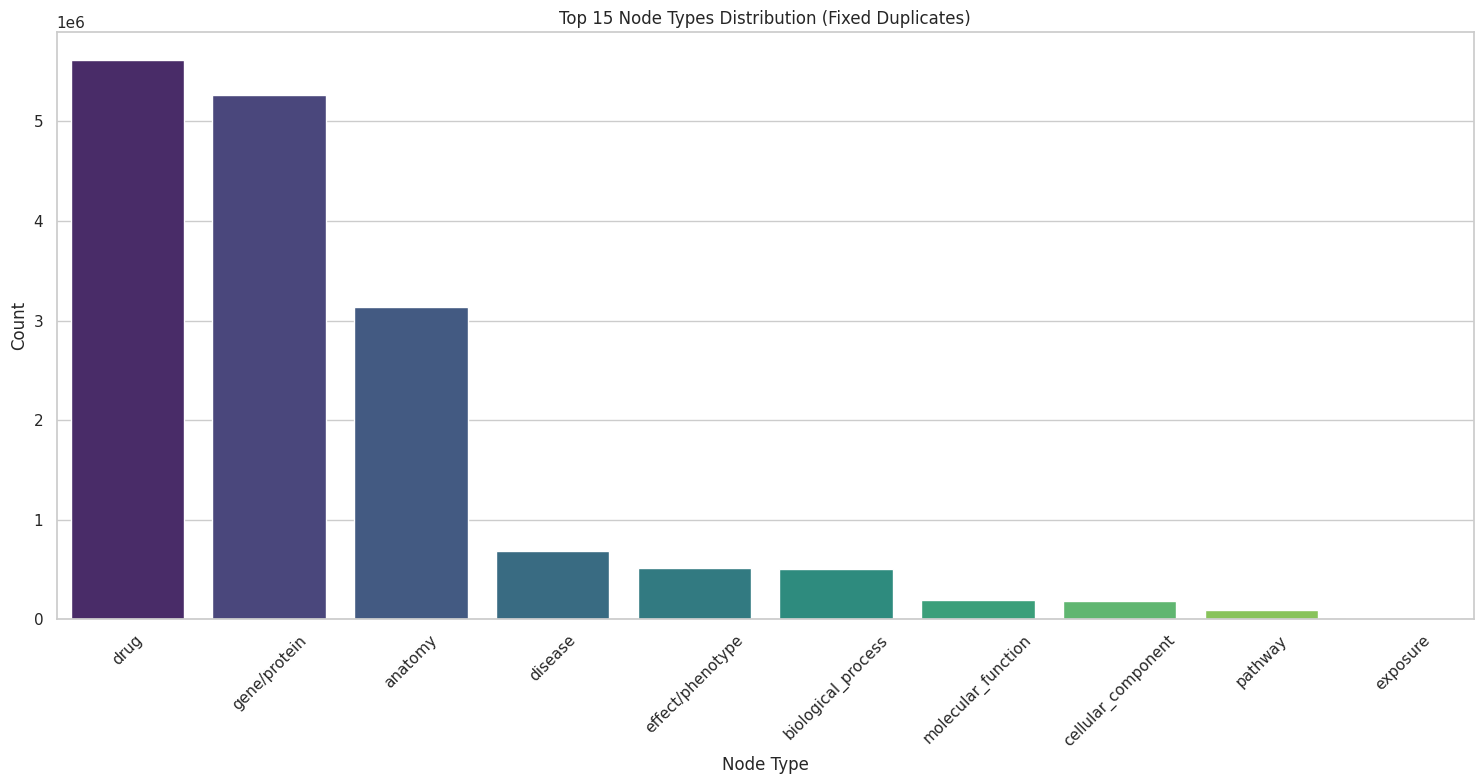

In [17]:


# 图 1: 节点类型分布 (Top 15)
plt.figure(figsize=(15, 8))
top_types = type_distribution.head(15) # 使用修复后的数据

plot_df = top_types.rename_axis("node_type").reset_index(name="count")
sns.barplot(
    data=plot_df,
    x="node_type",
    y="count",
    hue="node_type",      # 关键：显式 hue
    palette="viridis",
    legend=False          # 关键：关闭图例
)
plt.title('Top 15 Node Types Distribution (Fixed Duplicates)')
plt.xlabel('Node Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
# 保存图片
plt.savefig(f'{output_dir}/1_node_types.png', dpi=300)
plt.show()

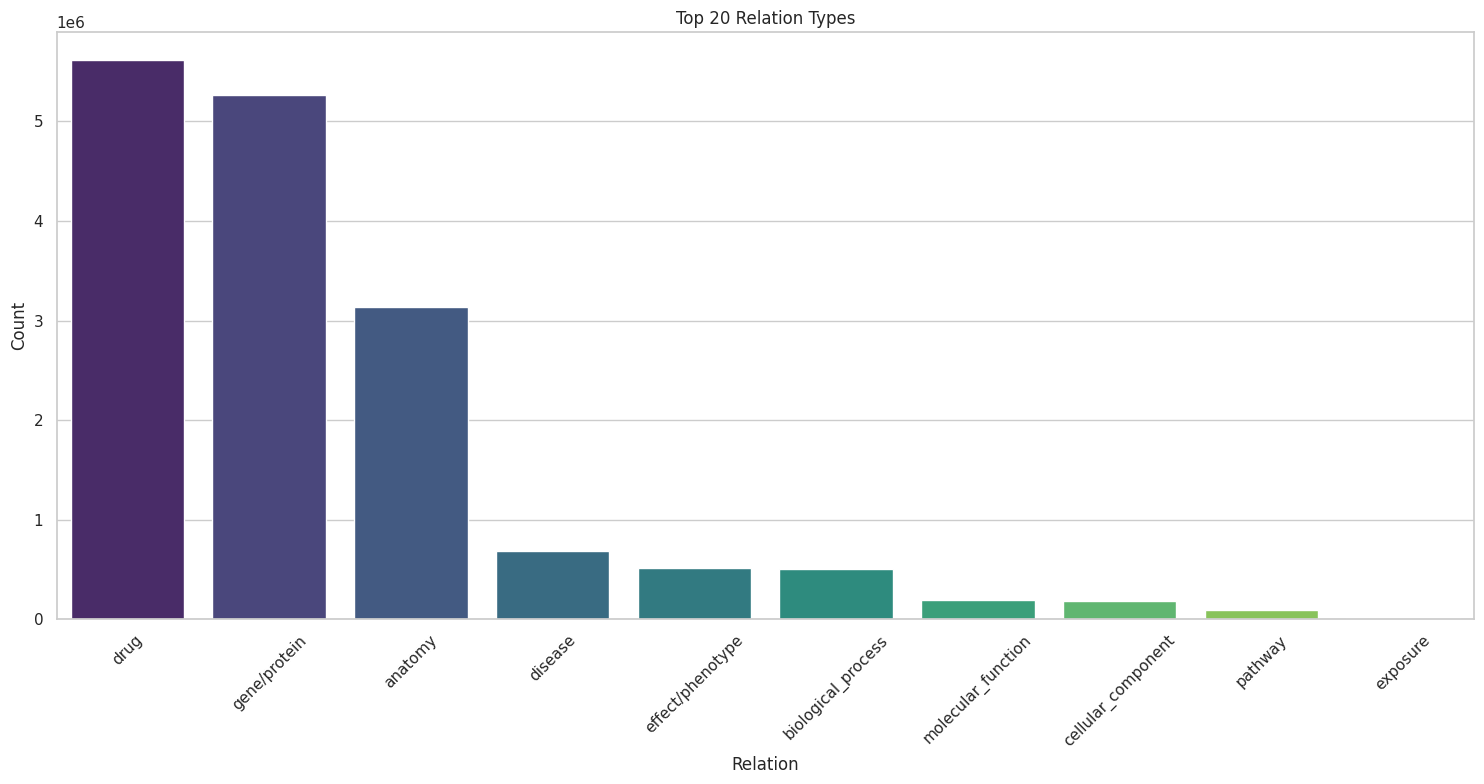

In [ ]:
# 图 2: 关系类型分布 (Top 20)
plt.figure(figsize=(15, 8))
top_rels = relation_counts.head(20)
plot_df = top_rels.rename_axis("relation").reset_index(name="count")  # ✅ 修正：使用 relation_counts

sns.barplot(
    data=plot_df,
    x="relation",
    y="count",
    hue="relation",
    palette="viridis",
    legend=False
)
plt.title('Top 20 Relation Types')
plt.xlabel('Relation')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # 可加 ha='right' 避免标签被截断
plt.tight_layout()
plt.savefig(f'{output_dir}/2_relation_types.png', dpi=300)
plt.show()

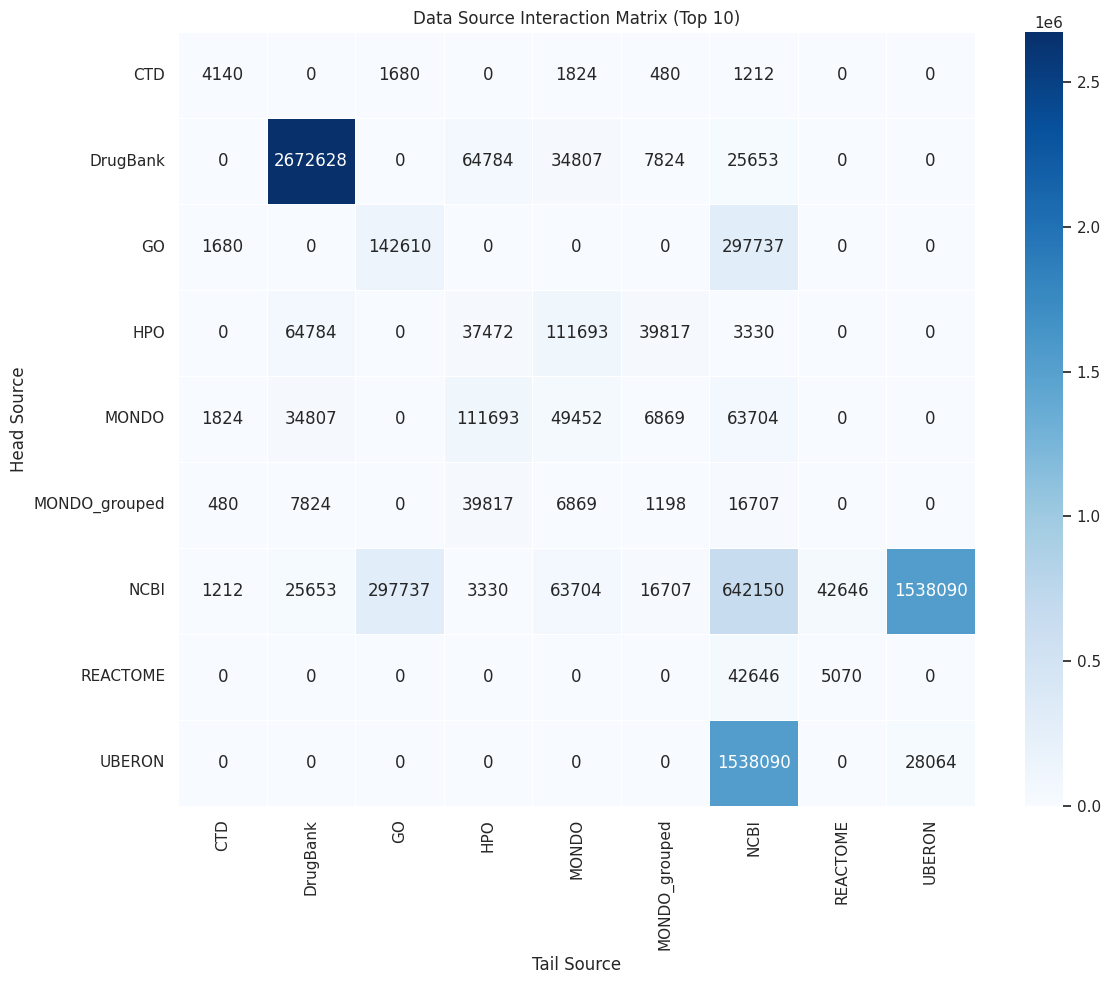

In [19]:

# 图 3: 数据源交互热力图
plt.figure(figsize=(12, 10))
top_10_sources = source_distribution.head(10).index # 使用修复后的数据
df_source_filtered = df[df['x_source'].isin(top_10_sources) & df['y_source'].isin(top_10_sources)]
heatmap_data = pd.crosstab(df_source_filtered['x_source'], df_source_filtered['y_source'])

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.title('Data Source Interaction Matrix (Top 10)')
plt.xlabel('Tail Source')
plt.ylabel('Head Source')
plt.tight_layout()
# 保存图片
plt.savefig(f'{output_dir}/3_source_heatmap.png', dpi=300)
plt.show()


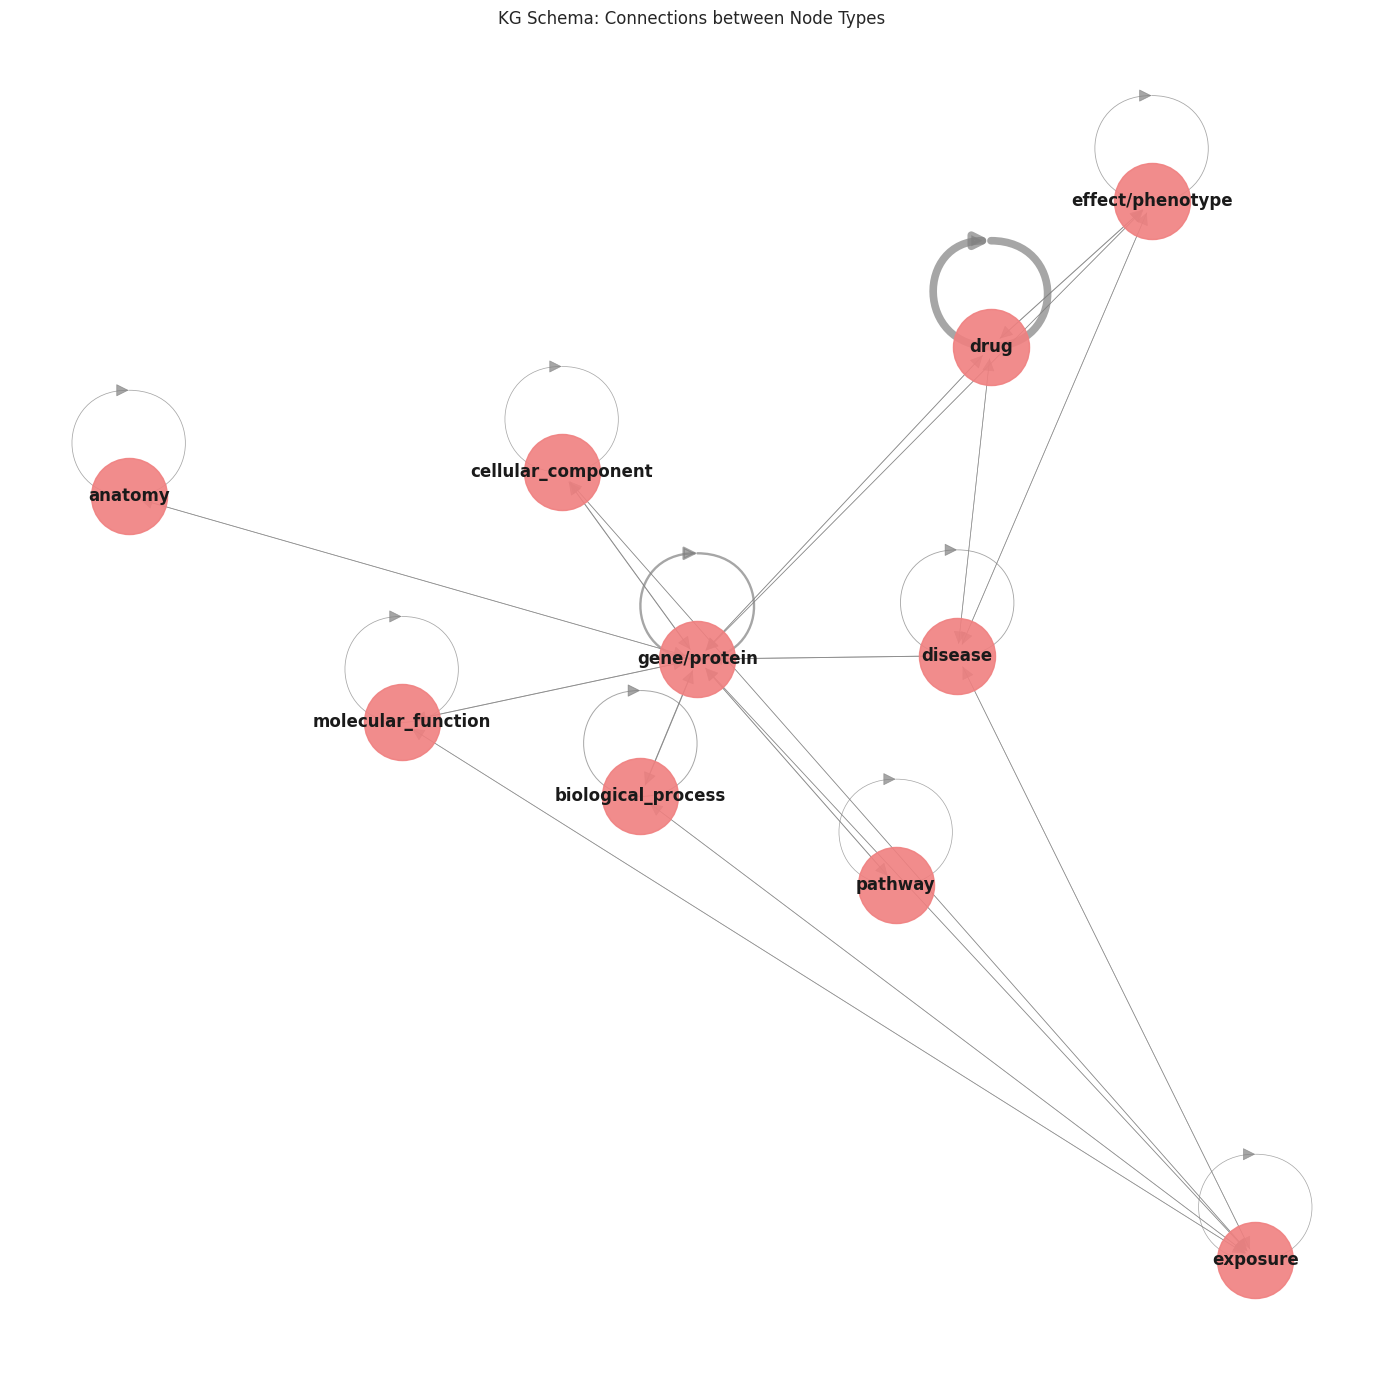

In [27]:

# 图 4: 异构图 Schema 网络图
G = nx.DiGraph()
for _, row in schema_patterns.iterrows():
    G.add_edge(row['x_type'], row['y_type'], weight=row['count'], label=row['relation'])

plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.6, iterations=100)
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightcoral', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
widths = [w / max(weights) * 5 + 0.5 if max(weights) > 0 else 1 for w in weights]
nx.draw_networkx_edges(G, pos, width=widths, edge_color='gray', arrows=True, arrowsize=20, alpha=0.7)

plt.title('KG Schema: Connections between Node Types')
plt.axis('off')
plt.tight_layout()
# 保存图片
plt.savefig(f'{output_dir}/4_schema_network.png', dpi=300)
plt.show()



In [ ]:
print("\n🎉 分析完成！")